The solution was presented using the Colab Generative AI Agent prompts. The demo also showed how to use the same prompts and data file with Claude. Most Generative AI tools should produce similar results. Note that each tool has its own capabilities, limitations, quirks, and

Prompt: How can I upload a csv file into colab?

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving marketing_campaign.csv to marketing_campaign.csv
User uploaded file "marketing_campaign.csv" with length 220188 bytes


Prompt: Of the CSV File, which features could be used for prediction?

In [ ]:
import pandas as pd

# The CSV file was uploaded as 'marketing_campaign.csv'
df = pd.read_csv('marketing_campaign.csv', sep='\t') # Assuming tab-separated based on 'uploaded' variable content

print("DataFrame Head:")
print(df.head())

print("\nDataFrame Info:")
df.info()


DataFrame Head:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \

Prompt: Which features could have an issue in terms of scale?

Prompt: Let's take the Income, the MntWines and the MntFruits and visualize it.

During the Demo wanted to make plots bigger to make them easier to visualize. Sometimes need to iterate with prompting like below.

Prompt: Lets make the plots bigger.
Prompt: Let's have one plot per line so that it renders bigger.

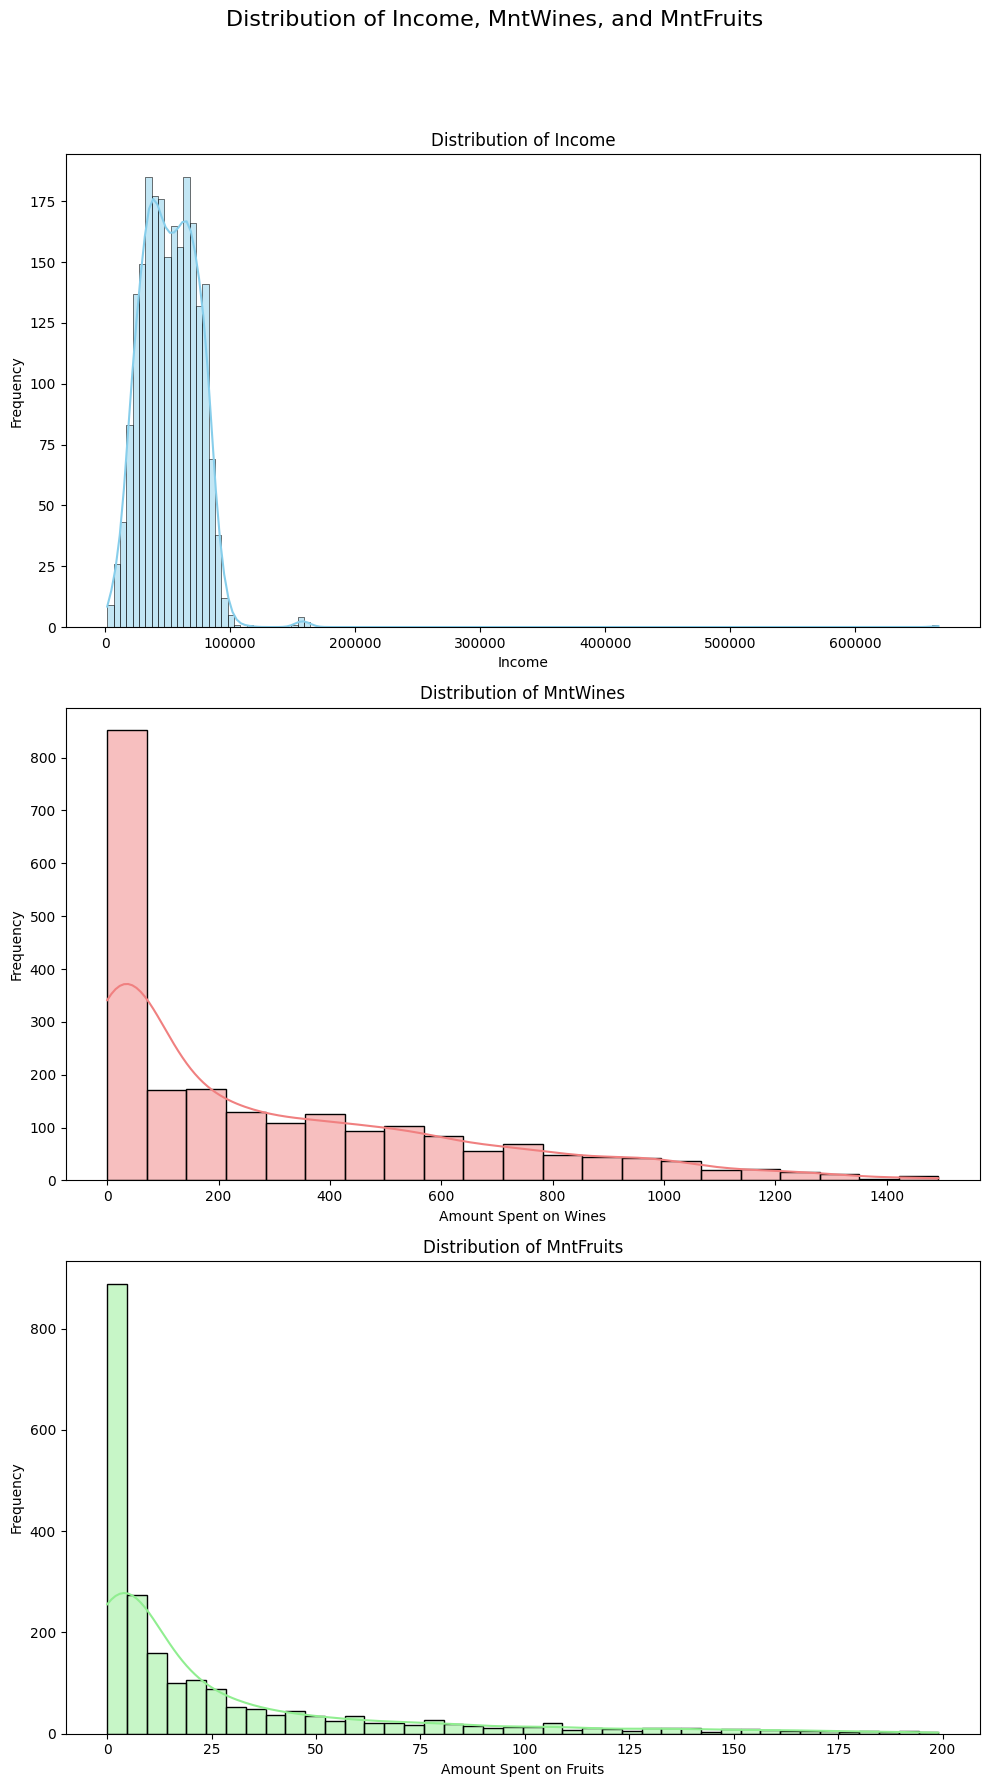

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop rows where 'Income' is NaN for visualization purposes
df_viz = df.dropna(subset=['Income']).copy()

fig, axes = plt.subplots(3, 1, figsize=(10, 18)) # Changed to 3 rows, 1 column, and adjusted figsize
fig.suptitle('Distribution of Income, MntWines, and MntFruits', fontsize=16, y=1.02)

# Histogram for Income
sns.histplot(df_viz['Income'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Income')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Frequency')

# Histogram for MntWines
sns.histplot(df_viz['MntWines'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of MntWines')
axes[1].set_xlabel('Amount Spent on Wines')
axes[1].set_ylabel('Frequency')

# Histogram for MntFruits
sns.histplot(df_viz['MntFruits'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of MntFruits')
axes[2].set_xlabel('Amount Spent on Fruits')
axes[2].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

Prompt: Let's scale these three features.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Define the features to be scaled
features_to_scale = ['Income', 'MntWines', 'MntFruits']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply the scaler to the selected features in df_viz
df_viz[features_to_scale] = scaler.fit_transform(df_viz[features_to_scale])

print("DataFrame head with scaled features:")
display(df_viz[features_to_scale].head())

DataFrame head with scaled features:


,Income,MntWines,MntFruits
0,0.234063,0.978226,1.549429
1,-0.234559,-0.872024,-0.637328
2,0.769478,0.358511,0.569159
3,-1.017239,-0.872024,-0.561922
4,0.240221,-0.391671,0.418348


Prompt: Visualize the distributions of the scaled features

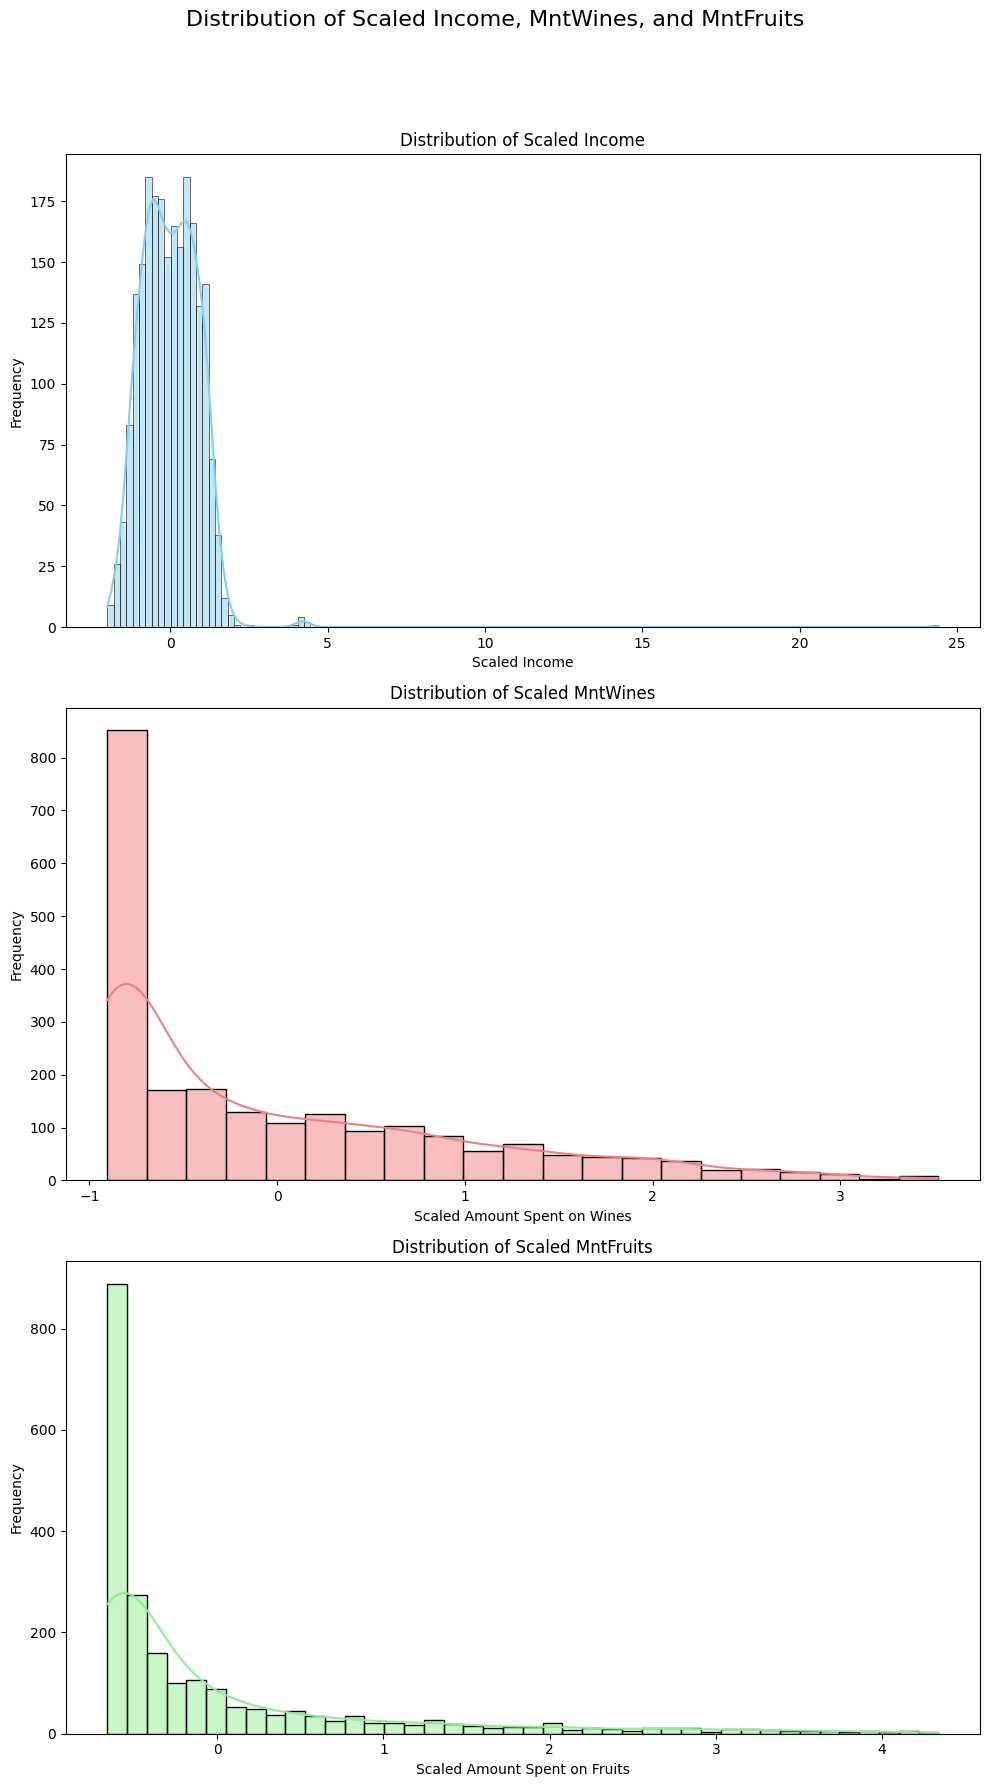

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(10, 18)) # 3 rows, 1 column
fig.suptitle('Distribution of Scaled Income, MntWines, and MntFruits', fontsize=16, y=1.02)

# Histogram for Scaled Income
sns.histplot(df_viz['Income'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Scaled Income')
axes[0].set_xlabel('Scaled Income')
axes[0].set_ylabel('Frequency')

# Histogram for Scaled MntWines
sns.histplot(df_viz['MntWines'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Scaled MntWines')
axes[1].set_xlabel('Scaled Amount Spent on Wines')
axes[1].set_ylabel('Frequency')

# Histogram for Scaled MntFruits
sns.histplot(df_viz['MntFruits'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Scaled MntFruits')
axes[2].set_xlabel('Scaled Amount Spent on Fruits')
axes[2].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()